In [1]:
from hems_resopt.components.ev import EV
from res_opt_core import Grid, EnergyModel, AuctionMarket, Load, RenewableProduction, plot_battery_operation, Battery
import pandas as pd
import numpy as np

In [2]:
# We use CHF and kWh/kW as units
start_time = pd.Timestamp('2025-03-23 00:00:00', tz='Europe/Zurich')
end_time = pd.Timestamp('2025-03-25 00:00:00', tz='Europe/Zurich')
time_idx = pd.date_range(start=start_time, end=end_time, freq='15min', inclusive='left')


# ==================== PV PRODUCTION ====================
# Simple sine curve for PV (100 kW peak)
hour_of_day = time_idx.hour + time_idx.minute / 60
pv_production = np.maximum(0, 100 * np.sin(np.pi * (hour_of_day - 6) / 12))

# ==================== BUILDING LOAD ====================
# Simple sine curve for building load (10-100 kW)
load_building = 55 + 45 * np.sin(np.pi * (hour_of_day - 6) / 12)

# ==================== DAY-AHEAD PRICE CURVE ====================
# Morning and evening peaks
da_price_curve = 0.08 + 0.04 * np.sin(np.pi * (hour_of_day - 7) / 6) + 0.03 * np.sin(np.pi * (hour_of_day - 18) / 6)


df_inputs = pd.DataFrame(
    index=time_idx,
    data={
        'power_max_grid': 1000,
        'pv_production': pv_production,
        'load_building': load_building,
        'da_price_curve': da_price_curve
    }
)

df_inputs

,power_max_grid,pv_production,load_building,da_price_curve
2025-03-23 00:00:00+01:00,1000,0.0,10.000000,0.100000
2025-03-23 00:15:00+01:00,1000,0.0,10.096348,0.091392
2025-03-23 00:30:00+01:00,1000,0.0,10.384981,0.082588
2025-03-23 00:45:00+01:00,1000,0.0,10.864662,0.073741
2025-03-23 01:00:00+01:00,1000,0.0,11.533338,0.065000
...,...,...,...,...
2025-03-24 22:45:00+01:00,1000,0.0,12.388144,0.135218
2025-03-24 23:00:00+01:00,1000,0.0,11.533338,0.129641
2025-03-24 23:15:00+01:00,1000,0.0,10.864662,0.123215
2025-03-24 23:30:00+01:00,1000,0.0,10.384981,0.116049


In [3]:
# ==================== EV FLEET DATA ====================
# Fleet: 5 EVs, 100 kWh each, 10 kW charging power
# All leave at 7am, 3 return at 12pm, all back at 6pm

# Initialize arrays
n_timesteps = len(time_idx)
energy_capacity = np.zeros(n_timesteps)
power_min = np.zeros(n_timesteps)
power_max = np.zeros(n_timesteps)
soc_min = np.full(n_timesteps, 0.0)
soc_max = np.full(n_timesteps, 1.0)
soc_default = np.zeros(n_timesteps)
energy_out_slot_end = np.full(n_timesteps, 0.0)
energy_in_slot_start = np.full(n_timesteps, 0.0)

# Define EV availability by hour
for i, ts in enumerate(time_idx):
    hour = ts.hour
    
    if 0 <= hour < 7:  # Night: 5 EVs connected
        energy_capacity[i] = 500  # 5 * 100 kWh
        power_min[i] = -100  # 5 * 20 kW charge
        power_max[i] = 0   
        if hour >= 6:
            energy_out_slot_end[i] = 500
    elif 7 <= hour < 12:  # Morning: 0 EVs
        energy_capacity[i] = 0
        power_min[i] = 0
        power_max[i] = 0
    elif 12 <= hour < 18:  # Lunch: 3 EVs
        energy_capacity[i] = 300  # 3 * 100 kWh
        power_min[i] = -60  
        power_max[i] = 0   # 3 * 20 kW charge
        #if hour == 12 and ts.minute == 0:
            #soc_default[i] = 0.25  # 3 EVs arrive with 25% SoC
    else:  # Evening: 5 EVs
        energy_capacity[i] = 500  # 5 * 100 kWh
        power_min[i] = -100  # 5 * 10 kW discharge
        power_max[i] = 0   # 5 * 20 kW charge
        #if hour == 18 and ts.minute == 0:
            #soc_default[i] = 0.25  # 2 more EVs arrive with 25% SoC



ev_data = pd.DataFrame(
    index=time_idx,
    data={
        'energy_capacity': energy_capacity+10,
        'power_min': power_min,
        'power_max': power_max,
        'soc_min': soc_min,
        'soc_max': soc_max
    }
)


In [4]:
ev_data['e_cap_diff']=ev_data['energy_capacity'].diff().fillna(0)
ev_data['e_in'] = ev_data['e_cap_diff'].clip(lower=0).abs() * 0.2
ev_data['e_out'] = ev_data['e_cap_diff'].clip(upper=0).abs().shift(-1).fillna(0)


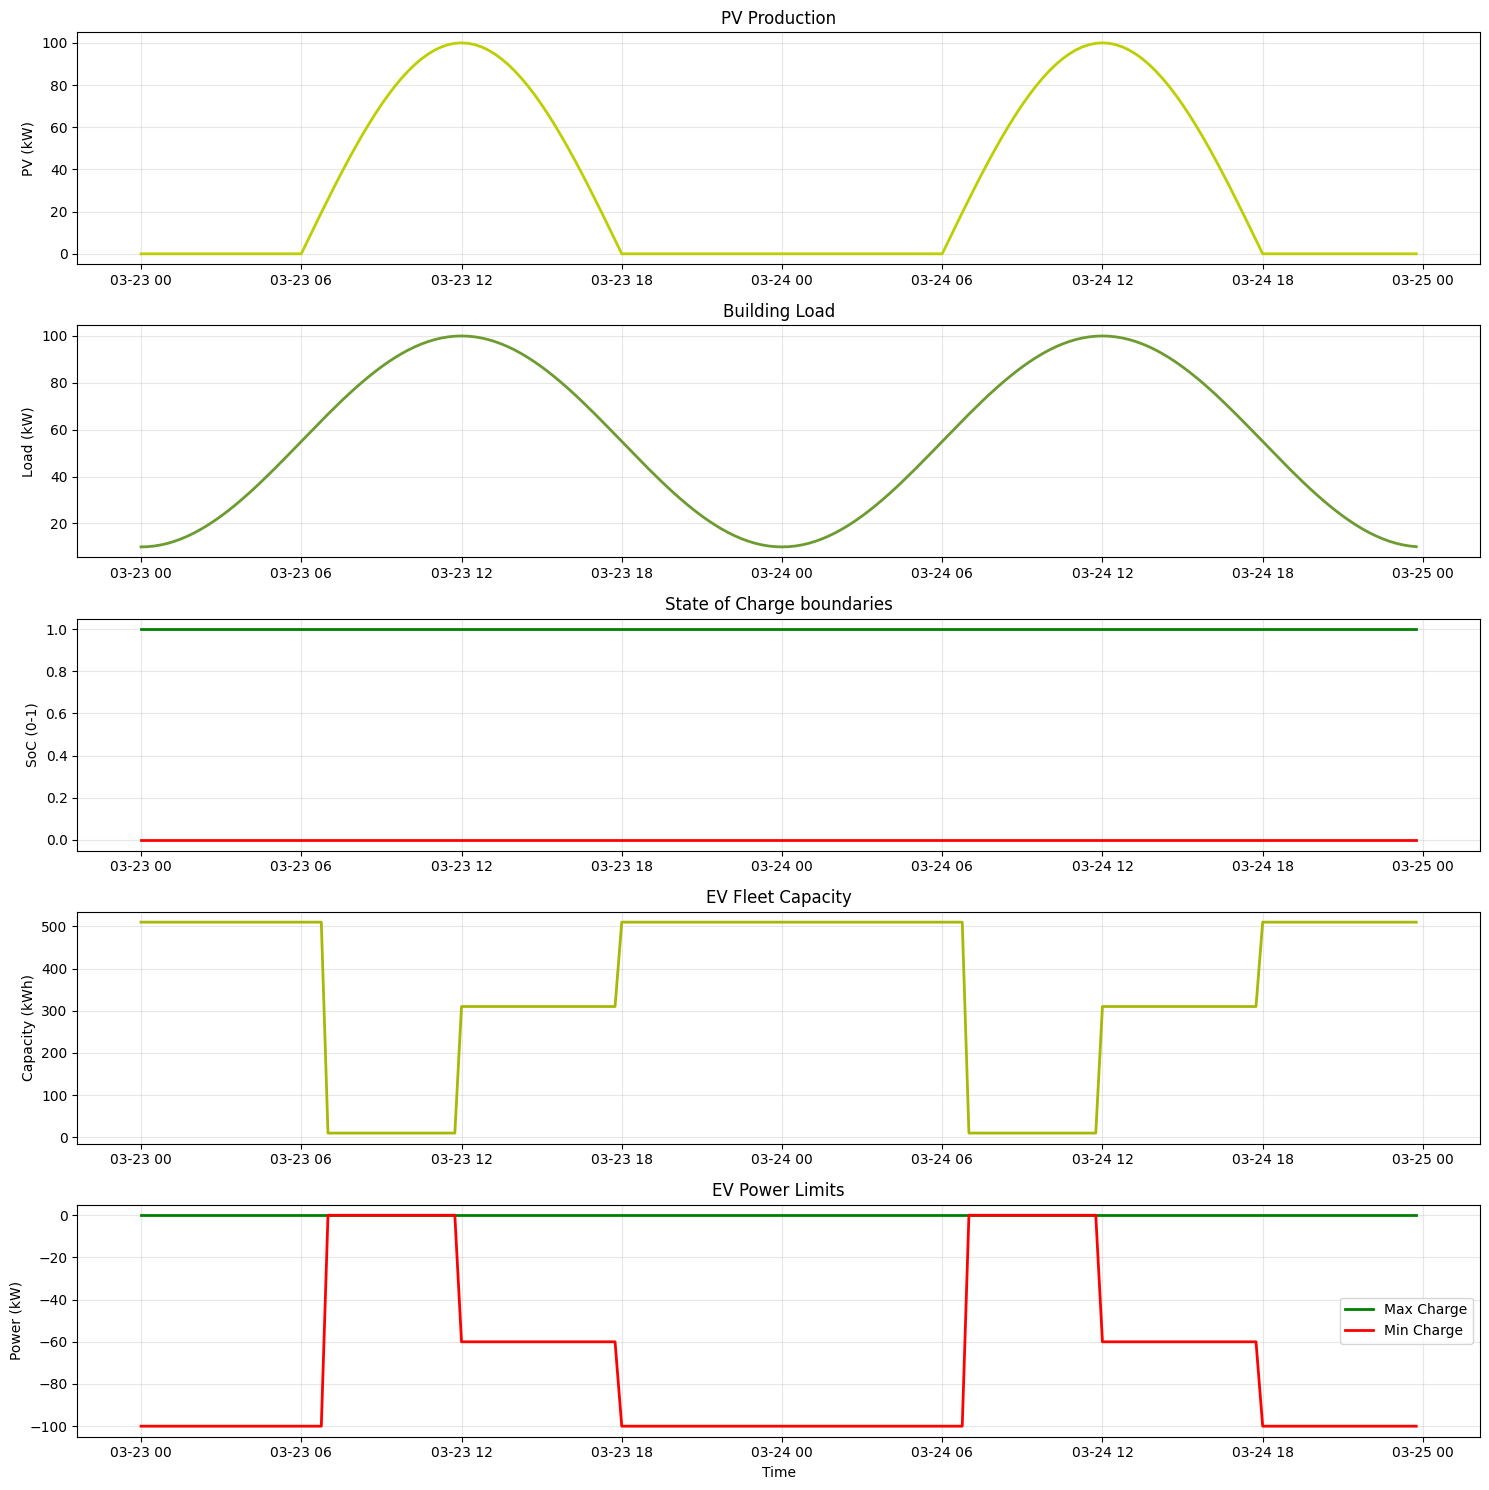

In [5]:
import matplotlib.pyplot as plt

# ==================== VISUALIZATION ====================
fig, axes = plt.subplots(5, 1, figsize=(15, 15))

# PV Production
axes[0].plot(df_inputs.index, df_inputs['pv_production'], color='#BCCF02', linewidth=2)
axes[0].set_ylabel('PV (kW)')
axes[0].set_title('PV Production')
axes[0].grid(True, alpha=0.3)

# laod or price
axes[1].plot(df_inputs.index, df_inputs['load_building'], color='#6C9C30', linewidth=2)
axes[1].set_ylabel('Load (kW)')
axes[1].set_title('Building Load')
axes[1].grid(True, alpha=0.3)

# EV Soc min und max
axes[2].plot(ev_data.index, ev_data['soc_max'], color='green', linewidth=2, label='Max SoC')
axes[2].plot(ev_data.index, ev_data['soc_min'], color='red', linewidth=2, label='Min SoC')
axes[2].set_ylabel('SoC (0-1)')
axes[2].set_title('State of Charge boundaries')
axes[2].grid(True, alpha=0.3)

# EV Capacity
axes[3].plot(ev_data.index, ev_data['energy_capacity'], color='#a7b805', linewidth=2)
axes[3].set_ylabel('Capacity (kWh)')
axes[3].set_title('EV Fleet Capacity')
axes[3].grid(True, alpha=0.3)

# EV Power
axes[4].plot(ev_data.index, ev_data['power_max'], color='green', linewidth=2, label='Max Charge')
axes[4].plot(ev_data.index, ev_data['power_min'], color='red', linewidth=2, label='Min Charge')
axes[4].set_ylabel('Power (kW)')
axes[4].set_xlabel('Time')
axes[4].set_title('EV Power Limits')
axes[4].legend()
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Set up to test 
model = EnergyModel(
    name='Logistik',
    num_steps=len(df_inputs.index),
    slot_length='15min',
    solver='scip'
)
PV = RenewableProduction(
                name='PV', 
                power_max=df_inputs['pv_production'],
                allow_spill=True,
                cost_spill=0.1)


Building = Load(
    name='Logistik_Zentrum',
    load_curve=df_inputs['load_building'],
    lost_load_allowed=True,
    value_of_lost_load=1000.0
)

EV_fleet = EV(
    name='ev_fleet',
    power_nominal=200, # How to handle power nominal -> max of all connected powers?
    power_min=ev_data['power_min'],
    power_max=ev_data['power_max'],
    energy_capacity=ev_data['energy_capacity'],
    soc_initial=0.5,
    soc_final=None,
    energy_in_slot_start=ev_data['e_in'],
    energy_out_slot_end=ev_data['e_out']
    # soc_default=ev_data['soc_default'],
    #soc_target=1 #what soc before all evs have left the pool 
    
)

DA = AuctionMarket(
    price_curve=df_inputs['da_price_curve'],
    market_time_unit='15min'
)

grid = Grid(
    assets=[PV, Building, EV_fleet],
    markets=[DA],
    power_max=1000,
    power_min=-1000,   # physical power line limits
    # grid_fees=0 ?
    )

model.add_component(Building)
model.add_component(PV)
model.add_component(EV_fleet)
model.add_component(grid)
model.add_component(DA)
model.build_and_run(silent=False)

SCIP version 10.0.0 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.0] [GitHash: 0c80fdd8e9]
Copyright (c) 2002-2025 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 8.0.0         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: 2207cfb2]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.1           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.1           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.88.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.7.0          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 4.0.3 

In [7]:
df_results = model.results.timeseries_to_pandas()
df_results

,Logistik_Zentrum__var_power,Logistik_Zentrum__var_power_reserve_up,Logistik_Zentrum__var_power_reserve_down,Logistik_Zentrum__var_lost_load,PV__var_power,PV__var_power_reserve_up,PV__var_power_reserve_down,PV__var_spill,ev_fleet__var_power,ev_fleet__var_power_reserve_up,...,ev_fleet__var_power_max_violation,ev_fleet__var_power_min_violation,ev_fleet__var_energy_reserve_up_slot_start,ev_fleet__var_energy_reserve_down_slot_start,ev_fleet__var_energy_reserve_up_slot_end,ev_fleet__var_energy_reserve_down_slot_end,ev_fleet__var_soc_min_soft_violation,ev_fleet__var_soc_max_soft_violation,auction_market__var_power,timestamp
timestamp,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00,-10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-10.000000,2000-01-01 00:00:00
2000-01-01 00:15:00,-10.096348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-10.096348,2000-01-01 00:15:00
2000-01-01 00:30:00,-10.384981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-10.384981,2000-01-01 00:30:00
2000-01-01 00:45:00,-10.864662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-10.864662,2000-01-01 00:45:00
2000-01-01 01:00:00,-11.533338,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-11.533338,2000-01-01 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000-01-02 22:45:00,-12.388144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-12.388144,2000-01-02 22:45:00
2000-01-02 23:00:00,-11.533338,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-11.533338,2000-01-02 23:00:00
2000-01-02 23:15:00,-10.864662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-10.864662,2000-01-02 23:15:00


In [8]:
plot_battery_operation(df_results.index, EV_fleet, {"DA-Market": df_inputs['da_price_curve']})